# 01 · Univariate Economic Metric Forecasting
---
**Purpose**: Forecast a single economic metric using a SARIMAX model with
optional structural-break dummies (no external covariates).

**Process overview**:
1. Load config values + actual data + benchmark data
2. Prepare train/test slices for two tuning horizons and one inference horizon
3. Tune SARIMAX hyperparameters on the tuning horizons
4. Select best params via half-life decay weighted MAPE (if `WEIGHTED_TUNING=True`)
5. Train the final model on the inference horizon and produce a forecast
6. Plot all horizons side-by-side with MAPE annotations


## 1 · Imports

In [89]:
import sys, datetime, warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

sys.path.insert(0, "./scripts")          # expose scripts/helpers.py
from scripts.helpers import (
    load_actual_data, load_benchmark_data,
    build_pred_df, get_benchmark,
    evaluate_pred_df, plot_results, plot_all_horizons,
    print_metrics,
)

from statsmodels.tsa.statespace.sarimax import SARIMAX
warnings.filterwarnings("ignore")


## 2 · Configuration
All user-facing settings live in the next cell. Update portfolio, metric,
dates, and benchmark labels there. No external config file is required.


In [90]:
# -- Portfolio / metric --------------------------------------------
portfolio     = "Buckeye"
sub_portfolio = "LP"          # set to None if no sub-portfolio
forecast_type = "Actual"
TARGET_METRIC = "Ending Outstanding Loans"

# -- Horizons (general names) --------------------------------------
H_TUNE_1 = {
    "train_start": "2021-12-31",
    "train_end":   "2023-12-31",
    "test_start":  "2024-01-31",
    "test_end":    "2024-12-31",
}
H_TUNE_2 = {
    "train_start": "2022-12-31",
    "train_end":   "2024-12-31",
    "test_start":  "2025-01-31",
    "test_end":    "2025-12-31",
}
H_INFER = {
    "train_start": "2023-12-31",
    "train_end":   "2025-12-31",
    "test_start":  "2026-01-31",
    "test_end":    "2026-12-31",
}

# -- Tuning strategy -----------------------------------------------
WEIGHTED_TUNING = True
TOP_N_TUNE_1    = 20

# -- Paths and benchmark source ------------------------------------
data_dir = "./data"
USE_DUMMY_BENCHMARK = True
DUMMY_BENCHMARK_PATH = "./data/dummy_metrics.csv"

S3_BUCKET   = "fmsp-sagemaker-rstudio-01"
S3_FOLDER   = "Forecasting/Buckeye"
METRICS_FILE = "Forecasting_Buckeye_combined_with_predata_v6.parquet"

# -- Benchmark labels for inference horizon overlay ----------------
BENCHMARK_LABELS_TUNE_1 = [
    "2024 0+12",
    "original base case",
]
BENCHMARK_LABELS_TUNE_2 = [
    "2025 0+12",
    "original base case",
]
BENCHMARK_LABELS_INFER = [
    "2026 0+12",
    "original base case",
]

print(f"Portfolio  : {portfolio} / {sub_portfolio}")
print(f"Metric     : {TARGET_METRIC}")
print(f"Weighted   : {WEIGHTED_TUNING}")


Portfolio  : Buckeye / LP
Metric     : Ending Outstanding Loans
Weighted   : True


## 3 · Data Loading

### 3.1 Actual data  
Loaded from `data/{portfolio}_{sub_portfolio}_Actual.csv`.  
Columns: `DATE` (index) + one column per metric.


In [91]:
data_df = load_actual_data(data_dir, portfolio, sub_portfolio, forecast_type)
print(f"Loaded  {len(data_df)} rows  ({data_df.index[0]} → {data_df.index[-1]})")
print(f"Columns : {list(data_df.columns)}")
data_df.head()


Loaded  64 rows  (2020-12-31 → 2026-03-31)
Columns : ['Ending Outstanding Loans', '60+ DQ Rate', 'Expected Loss Rate']


,Ending Outstanding Loans,60+ DQ Rate,Expected Loss Rate
DATE,,,
2020-12-31,2.975000e+08,0.019000,0.040866
2021-01-31,2.990000e+08,0.020000,0.041000
2021-02-28,3.005000e+08,0.021000,0.040866
2021-03-31,3.013301e+08,0.021732,0.040500
2021-04-30,3.010000e+08,0.022000,0.040000


### 3.2 Benchmark / base-case data
Optional overlay series such as "2024 0+12" or "original base case".
Set `USE_DUMMY_BENCHMARK` to switch between local CSV and S3.


In [92]:
if USE_DUMMY_BENCHMARK:
    metric_df = pd.read_csv(DUMMY_BENCHMARK_PATH)
    metric_df["DATE"] = pd.to_datetime(metric_df["DATE"]).dt.date
else:
    metric_df = load_benchmark_data(
        bucket       = S3_BUCKET,
        folder       = S3_FOLDER,
        metrics_file = METRICS_FILE,
    )

print(f"Benchmark rows : {len(metric_df)}")
print(f"FORECAST_TYPEs : {metric_df['FORECAST_TYPE'].unique().tolist()}")


Benchmark rows : 48
FORECAST_TYPEs : ['2024 0+12', '2025 0+12', 'original base case']


## 4 · Horizon Slicing

For the inference horizon, actuals may be missing for later months. We
still build the full test index and evaluate metrics only where actuals exist.


In [93]:
def build_test_index(horizon: dict) -> pd.Index:
    return pd.date_range(horizon["test_start"], horizon["test_end"], freq="ME").date


def slice_horizon_full(data_df: pd.DataFrame, horizon: dict) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_start = datetime.date.fromisoformat(horizon["train_start"])
    train_end   = datetime.date.fromisoformat(horizon["train_end"])
    train_df = data_df[(data_df.index >= train_start) & (data_df.index <= train_end)]

    test_index = build_test_index(horizon)
    test_df = data_df.reindex(test_index)
    return train_df, test_df


train_t1, test_t1 = slice_horizon_full(data_df, H_TUNE_1)
train_t2, test_t2 = slice_horizon_full(data_df, H_TUNE_2)
train_inf, test_inf = slice_horizon_full(data_df, H_INFER)

for label, tr, te in [
    ("Tune 1", train_t1, test_t1),
    ("Tune 2", train_t2, test_t2),
    ("Inference", train_inf, test_inf),
]:
    actuals = int(te[TARGET_METRIC].notna().sum()) if TARGET_METRIC in te else 0
    print(
        f"{label}  train: {len(tr)} rows ({tr.index[0]} -> {tr.index[-1]})  "
        f"test: {len(te)} rows (actuals: {actuals})"
    )


Tune 1  train: 25 rows (2021-12-31 -> 2023-12-31)  test: 12 rows (actuals: 12)
Tune 2  train: 25 rows (2022-12-31 -> 2024-12-31)  test: 12 rows (actuals: 12)
Inference  train: 25 rows (2023-12-31 -> 2025-12-31)  test: 12 rows (actuals: 3)


## 5 · Structural-Break / Data-Lift Dummies
Use step dummies to capture one-time shifts (portfolio acquisition, policy
change, back-book transfers). This helps SARIMAX separate structural lifts
from stochastic trend.

- A dummy is 1 during the lift window and 0 elsewhere.
- Add multiple dummies if you have multiple known breaks.
- Set `exog_cols = []` for a fully univariate run.

``Note : This comming from data analysis``

In [94]:
# -- Define structural-break dummies -------------------------------
# Each dummy = 1 during the period where the structural change is
# active, 0 elsewhere. Adjust cut-off dates to match your data.

ACQUISITION_DATE = datetime.date.fromisoformat("2022-07-31")

def add_dummies(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Step dummy: 1 on/before acquisition, 0 after
    df["Portfolio_Acquired"] = (df.index <= ACQUISITION_DATE).astype(int)
    # -- Add further dummies here if needed -------------------------
    # df["Another_Event"] = (df.index <= datetime.date(2021, 3, 31)).astype(int)
    return df

train_t1 = add_dummies(train_t1)
test_t1  = add_dummies(test_t1)
train_t2 = add_dummies(train_t2)
test_t2  = add_dummies(test_t2)
train_inf = add_dummies(train_inf)
test_inf  = add_dummies(test_inf)

# -- Columns used as exogenous regressors ---------------------------
exog_cols = ["Portfolio_Acquired"]   # set to [] for univariate

# -- Endog / exog series --------------------------------------------
def split_y_exog(df, metric, cols):
    y    = df[metric].astype(float)
    exog = df[cols] if cols else None
    return y, exog

train_y_t1, train_x_t1 = split_y_exog(train_t1, TARGET_METRIC, exog_cols)
test_y_t1,  test_x_t1  = split_y_exog(test_t1,  TARGET_METRIC, exog_cols)

train_y_t2, train_x_t2 = split_y_exog(train_t2, TARGET_METRIC, exog_cols)
test_y_t2,  test_x_t2  = split_y_exog(test_t2,  TARGET_METRIC, exog_cols)

train_y_inf, train_x_inf = split_y_exog(train_inf, TARGET_METRIC, exog_cols)
test_y_inf,  test_x_inf  = split_y_exog(test_inf,  TARGET_METRIC, exog_cols)

print(f"Exog columns used: {exog_cols if exog_cols else 'None (univariate)'}")


Exog columns used: ['Portfolio_Acquired']


## 6 · Hyperparameter Grid & Tuning Function

### 6.1 Search grid

The `tune_sarimax` function iterates over the defined hyperparameter grid, fits each model combination on `train_y`, generates a 12-step-ahead forecast, and records the MAPE to identify the best-performing configuration.

#### Understanding SARIMAX Parameters
SARIMAX models combine non-seasonal and seasonal components, denoted as `(p, d, q) × (P, D, Q, m)`. Understanding what each parameter does is critical for defining a logical grid:

**Non-Seasonal Parameters (Short-term dynamics):**
*   **`p` (AutoRegressive - AR):** The number of immediate past values used to predict the current value. It captures the "momentum" of the series.
*   **`d` (Differencing - I):** The number of times the data is differenced to make it stationary. `d=1` means we look at the period-over-period change rather than the raw value.
*   **`q` (Moving Average - MA):** The number of past forecast errors used to predict the current value. It helps the model adjust to sudden, short-term "shocks."

**Seasonal Parameters (Long-term cycles):**
*   **`P, D, Q`:** These function exactly like `p, d, q`, but they operate across the seasonal period. For example, a seasonal AR of `P=1` means the model looks at what happened exactly one year ago to predict today.
*   **`m` (Seasonal Period):** The frequency of the cycle (e.g., `m=12` for monthly data).

#### Essential Guidelines for Grid Selection
Defining the hyperparameter grid requires careful attention to the characteristics of your specific training data:

*   **Time-Bound Characteristics:** The parameter grid should be tailored to the specific training period of the inference year. Economic and portfolio data characteristics change over time. A model structure that perfectly captured 2020's volatility might fail on 2023's stabilization. Always visually inspect the specific training slice.
*   **The Stationarity Catch-22:** SARIMAX strictly requires the input data to be stationary (constant mean and variance). While differencing (`d`, `D`) is the primary tool to achieve this, **over-differencing** can actually inject artificial noise or induce non-stationarity. 
*   **The Data Loss Penalty:** Every level of differencing consumes data. 
    *   Using `d=1` costs you **1 data point**.
    *   Using `D=1` costs you **12 data points**.
    *   Using both (`d=1, D=1`) strips **13 data points** from your training set. 
    *   *Why this matters:* If your training window is short, losing 12+ data points drastically reduces the model's ability to fit parameters accurately. This is especially problematic if you are trying to fit a constant trend (`trend='c'`), as the model has too few degrees of freedom left to calculate a reliable slope.

#### General Best Practices
*   **Treat Structural Breaks with Dummies:** If the series has a clear level shift (e.g., a portfolio acquisition or a macro-economic shock), use exogenous step dummies rather than relying on high differencing (`d`) to fix the jump.
*   **Prioritize Parsimony:** High values of `p` or `q` (e.g., > 2) combined with seasonal parameters easily lead to overfitting, especially on small sample sizes. Keep ranges modest; a simpler model almost always forecasts unseen data better than a highly complex one.



In [95]:
# ── SARIMAX search grid ───────────────────────────────────────────
# (p, d, q) → non-seasonal AR, integration, MA orders
# (P, D, Q) → seasonal AR, integration, MA orders; m = 12 (monthly)
_GRID = list(itertools.product(
    [0, 1, 2],   # p  — AR order
    [0, 1],      # d  — differencing
    [0, 1],      # q  — MA order
    [0, 1],      # P  — seasonal AR
    [0],         # D  — seasonal differencing (fixed; avoids over-differencing)
    [0, 1],      # Q  — seasonal MA
))
_M = 12   # seasonal period (monthly data)

print(f"Grid size: {len(_GRID)} candidate configurations")


Grid size: 48 candidate configurations


### 6.2 Tuning helper
`tune_sarimax` iterates over the grid, fits each model on `train_y`,
generates a 12-step-ahead forecast, and records the MAPE.

SARIMAX parameter notes (monthly data):
- `p, d, q` control short-run AR, differencing, and MA behavior.
- `P, D, Q` control seasonal dynamics at period `m=12`.
- High `p` or `q` can overfit on short samples; keep ranges modest.
- If the series has a clear level shift, use dummies and keep `d` small.


In [96]:
def tune_sarimax(
    train_y:   pd.Series,
    test_y:    pd.Series,
    train_exog = None,
    test_exog  = None,
    grid       = _GRID,
    m: int     = _M,
) -> pd.DataFrame:
    """
    Grid-search SARIMAX hyperparameters, return a DataFrame of results
    sorted by MAPE (ascending).

    Parameters
    ----------
    train_y / test_y   : endogenous train and validation series
    train_exog / test_exog : exogenous DataFrames (None for univariate)
    grid               : list of (p, d, q, P, D, Q) tuples
    m                  : seasonal period

    Returns
    -------
    DataFrame columns: p, d, q, P, D, Q, MAPE
    """
    rows = []
    for p, d, q, P, D, Q in grid:
        try:
            model = SARIMAX(
                train_y,
                exog           = train_exog,
                order          = (p, d, q),
                seasonal_order = (P, D, Q, m),
                trend          = "n",
                enforce_stationarity  = False,
                enforce_invertibility = False,
            ).fit(disp=False)

            fc = model.get_forecast(
                steps = len(test_y),
                exog  = test_exog,
            ).predicted_mean.values

            yt   = test_y.values.astype(float)
            mape = float(np.mean(np.abs((yt - fc) / yt)) * 100)

            rows.append({
                "p": p, "d": d, "q": q,
                "P": P, "D": D, "Q": Q,
                "MAPE": round(mape, 4),
            })
        except Exception:
            pass   # numerical failure → skip configuration

    return (
        pd.DataFrame(rows)
        .sort_values("MAPE")
        .reset_index(drop=True)
    )


PARAM_COLS = ["p", "d", "q", "P", "D", "Q"]


## 7 · Hyperparameter Tuning

### 7.1 Tune on horizon 1
Train on the first tuning window, evaluate on its test window.
(Skipped automatically when `WEIGHTED_TUNING = False`.)


In [97]:
if WEIGHTED_TUNING:
    print("Tuning on horizon 1 ...")
    df_tune_h1 = tune_sarimax(train_y_t1, test_y_t1, train_x_t1, test_x_t1)
    print(f"  Completed - {len(df_tune_h1)} valid configurations")
    print("  Top 5:")
    display(df_tune_h1.head(5))
else:
    df_tune_h1 = pd.DataFrame(columns=PARAM_COLS + ["MAPE"])
    print("WEIGHTED_TUNING=False -> horizon 1 tuning skipped.")


Tuning on horizon 1 ...
  Completed - 48 valid configurations
  Top 5:


,p,d,q,P,D,Q,MAPE
0,0,1,1,1,0,0,0.0000
1,0,1,0,1,0,0,0.0000
2,0,0,0,1,0,0,0.1111
3,1,0,1,0,0,1,1.2978
4,1,0,1,1,0,1,1.2980


### 7.2 Tune on horizon 2
Train on the second tuning window, evaluate on its test window.
Always executed (used as the sole basis when `WEIGHTED_TUNING = False`).


In [98]:
print("Tuning on horizon 2 ...")
df_tune_h2 = tune_sarimax(train_y_t2, test_y_t2, train_x_t2, test_x_t2)
print(f"  Completed - {len(df_tune_h2)} valid configurations")
print("  Top 5:")
display(df_tune_h2.head(5))


Tuning on horizon 2 ...
  Completed - 48 valid configurations
  Top 5:


,p,d,q,P,D,Q,MAPE
0,0,1,0,1,0,0,0.0000
1,1,1,0,1,0,0,0.0000
2,2,1,0,1,0,0,0.0000
3,2,1,1,1,0,0,0.0000
4,1,0,0,1,0,0,0.0002


## 8 · Best Hyperparameter Selection

### 8.1 Half-life decay weighting (when `WEIGHTED_TUNING = True`)

The recency-weighted average MAPE is computed as:

$$\text{Avg MAPE} = w_{h2} \cdot \text{MAPE}_{h2} + w_{h1} \cdot \text{MAPE}_{h1}$$

Weights follow half-life decay with $\lambda = 1$:

$$w_{h2} = \frac{(\tfrac{1}{2})^0}{(\tfrac{1}{2})^0 + (\tfrac{1}{2})^1} = \frac{2}{3}$$
$$w_{h1} = \frac{(\tfrac{1}{2})^1}{(\tfrac{1}{2})^0 + (\tfrac{1}{2})^1} = \frac{1}{3}$$

Only the top-N horizon-1 results are included in the merge to reduce
old-horizon overfitting.

### 8.2 Horizon-2 only (when `WEIGHTED_TUNING = False`)
The best configuration is simply `df_tune_h2.iloc[0]`.


In [99]:
# Half-life decay weights (lambda = 1, two periods: h2 = age 0, h1 = age 1)
W_H2 = (0.5 ** 0) / ((0.5 ** 0) + (0.5 ** 1))   # ~0.667
W_H1 = (0.5 ** 1) / ((0.5 ** 0) + (0.5 ** 1))   # ~0.333

if WEIGHTED_TUNING and not df_tune_h1.empty:
    # Keep only top-N from horizon 1 to reduce old-horizon overfitting
    top_h1 = df_tune_h1.head(TOP_N_TUNE_1)

    # Inner join: only configs that appear in BOTH tuning results
    combined = pd.merge(
        top_h1[PARAM_COLS + ["MAPE"]].rename(columns={"MAPE": "MAPE_H1"}),
        df_tune_h2[PARAM_COLS + ["MAPE"]].rename(columns={"MAPE": "MAPE_H2"}),
        on  = PARAM_COLS,
        how = "inner",
    )
    # Weighted average MAPE
    combined["Avg_MAPE"] = W_H2 * combined["MAPE_H2"] + W_H1 * combined["MAPE_H1"]
    combined = combined.sort_values("Avg_MAPE").reset_index(drop=True)

    print(f"Weighted tuning - {len(combined)} configs in common")
    print(f"  Weights: h2={W_H2:.3f}  h1={W_H1:.3f}")
    display(combined.head(5))

    best_params = combined.iloc[0]
else:
    # Horizon-2 only selection
    best_params = df_tune_h2.iloc[0]
    print("Horizon-2 only hyperparameter selection.")

print("\n--- Best Hyperparameters ---")
print(f"  order          = ({int(best_params.p)}, {int(best_params.d)}, {int(best_params.q)})")
print(f"  seasonal_order = ({int(best_params.P)}, {int(best_params.D)}, {int(best_params.Q)}, {_M})")


Weighted tuning - 20 configs in common
  Weights: h2=0.667  h1=0.333


,p,d,q,P,D,Q,MAPE_H1,MAPE_H2,Avg_MAPE
0,0,1,0,1,0,0,0.0000,0.0000,0.000000
1,0,0,0,1,0,0,0.1111,0.2289,0.189633
2,2,0,0,1,0,0,1.4063,0.0005,0.469100
3,1,0,0,1,0,0,1.5622,0.0002,0.520867
4,1,0,1,1,0,0,1.3396,0.1120,0.521200



--- Best Hyperparameters ---
  order          = (0, 1, 0)
  seasonal_order = (1, 0, 0, 12)


## 9 · Fit Models on Horizons

### 9.1 Standard (direct) forecast for tuning horizons

We refit the models - one per horizon - using the same best
hyperparameters. The tuning horizons are for diagnostics; the inference
horizon produces the production forecast.


In [100]:
def fit_and_forecast(
    train_y, test_y,
    train_exog, test_exog,
    params, m: int = _M,
    model_label: str = "SARIMAX",
) -> tuple:
    """
    Fit SARIMAX with the given params and return (pred_df, result).

    Returns
    -------
    pred_df : long-format DataFrame (Actual + model_label)
    result  : fitted SARIMAX result object
    """
    p, d, q = int(params.p), int(params.d), int(params.q)
    P, D, Q = int(params.P), int(params.D), int(params.Q)

    result = SARIMAX(
        train_y,
        exog           = train_exog,
        order          = (p, d, q),
        seasonal_order = (P, D, Q, m),
        trend          = "n",
        enforce_stationarity  = False,
        enforce_invertibility = False,
    ).fit(disp=False)

    fc = result.get_forecast(
        steps = len(test_y),
        exog  = test_exog,
    ).predicted_mean
    fc.index = test_y.index

    pred_df = build_pred_df(fc.values, test_y, model_label=model_label)
    return pred_df, result


# -- Horizon 1 ------------------------------------------------------
pred_df_h1, result_h1 = fit_and_forecast(
    train_y_t1, test_y_t1, train_x_t1, test_x_t1, best_params
)
# -- Horizon 2 ------------------------------------------------------
pred_df_h2, result_h2 = fit_and_forecast(
    train_y_t2, test_y_t2, train_x_t2, test_x_t2, best_params
)

print("Diagnostic models (horizon 1, horizon 2) fitted.")


Diagnostic models (horizon 1, horizon 2) fitted.


### 9.2 Add Benchmark Series to Tuning Horizons


In [102]:
# After pred_df_h1 is created - add benchmarks for horizon-1 overlay
benchmark_frames_h1 = []
for label in BENCHMARK_LABELS_TUNE_1:
    bdf = get_benchmark(
        metric_df, portfolio, sub_portfolio,
        TARGET_METRIC, test_y_t1.index, label,
    )
    if not bdf.empty:
        benchmark_frames_h1.append(bdf)

pred_df_h1 = build_pred_df(
    forecast_values = pred_df_h1[pred_df_h1["FORECAST_TYPE"] == "SARIMAX"]["METRIC_VALUE"].values,
    test_series     = test_y_t1,
    model_label     = "SARIMAX",
    benchmark_dfs   = benchmark_frames_h1,
)

# After pred_df_h2 is created - add benchmarks for horizon-2 overlay
benchmark_frames_h2 = []
for label in BENCHMARK_LABELS_TUNE_2:
    bdf = get_benchmark(
        metric_df, portfolio, sub_portfolio,
        TARGET_METRIC, test_y_t2.index, label,
    )
    if not bdf.empty:
        benchmark_frames_h2.append(bdf)

pred_df_h2 = build_pred_df(
    forecast_values = pred_df_h2[pred_df_h2["FORECAST_TYPE"] == "SARIMAX"]["METRIC_VALUE"].values,
    test_series     = test_y_t2,
    model_label     = "SARIMAX",
    benchmark_dfs   = benchmark_frames_h2,
)


### 9.3 Error metrics per horizon

In [104]:
def drop_missing_actuals(pred_df: pd.DataFrame) -> pd.DataFrame:
    mask = ~(
        (pred_df["FORECAST_TYPE"] == "Actual")
        & (pred_df["METRIC_VALUE"].isna())
    )
    return pred_df.loc[mask].copy()

# Horizon 1 metrics
clean_h1 = drop_missing_actuals(pred_df_h1)
if clean_h1[clean_h1["FORECAST_TYPE"] == "Actual"].empty:
    print("\nHorizon 1 - no actuals available for evaluation.")
else:
    evaluate_pred_df(clean_h1, "SARIMAX", TARGET_METRIC)

# Horizon 2 metrics
clean_h2 = drop_missing_actuals(pred_df_h2)
if clean_h2[clean_h2["FORECAST_TYPE"] == "Actual"].empty:
    print("\nHorizon 2 - no actuals available for evaluation.")
else:
    evaluate_pred_df(
        clean_h2,
        ["SARIMAX"] + BENCHMARK_LABELS_TUNE_2,
        TARGET_METRIC,
    )



═══════════════════════════════════════════════════════
  Error Metrics — Ending Outstanding Loans
═══════════════════════════════════════════════════════
  SARIMAX
    MAPE  : 0.00%
    SMAPE : 0.00%
    MAE   :                0
    RMSE  :                0
═══════════════════════════════════════════════════════

═══════════════════════════════════════════════════════
  Error Metrics — Ending Outstanding Loans
═══════════════════════════════════════════════════════
  SARIMAX
    MAPE  : 0.00%
    SMAPE : 0.00%
    MAE   :                0
    RMSE  :                0
  2025 0+12
    MAPE  : 1.63%
    SMAPE : 1.62%
    MAE   :        4,000,000
    RMSE  :        4,000,000
  original base case
    MAPE  : 0.82%
    SMAPE : 0.81%
    MAE   :        2,000,000
    RMSE  :        2,000,000
═══════════════════════════════════════════════════════


### 9.4 Individual horizon plots

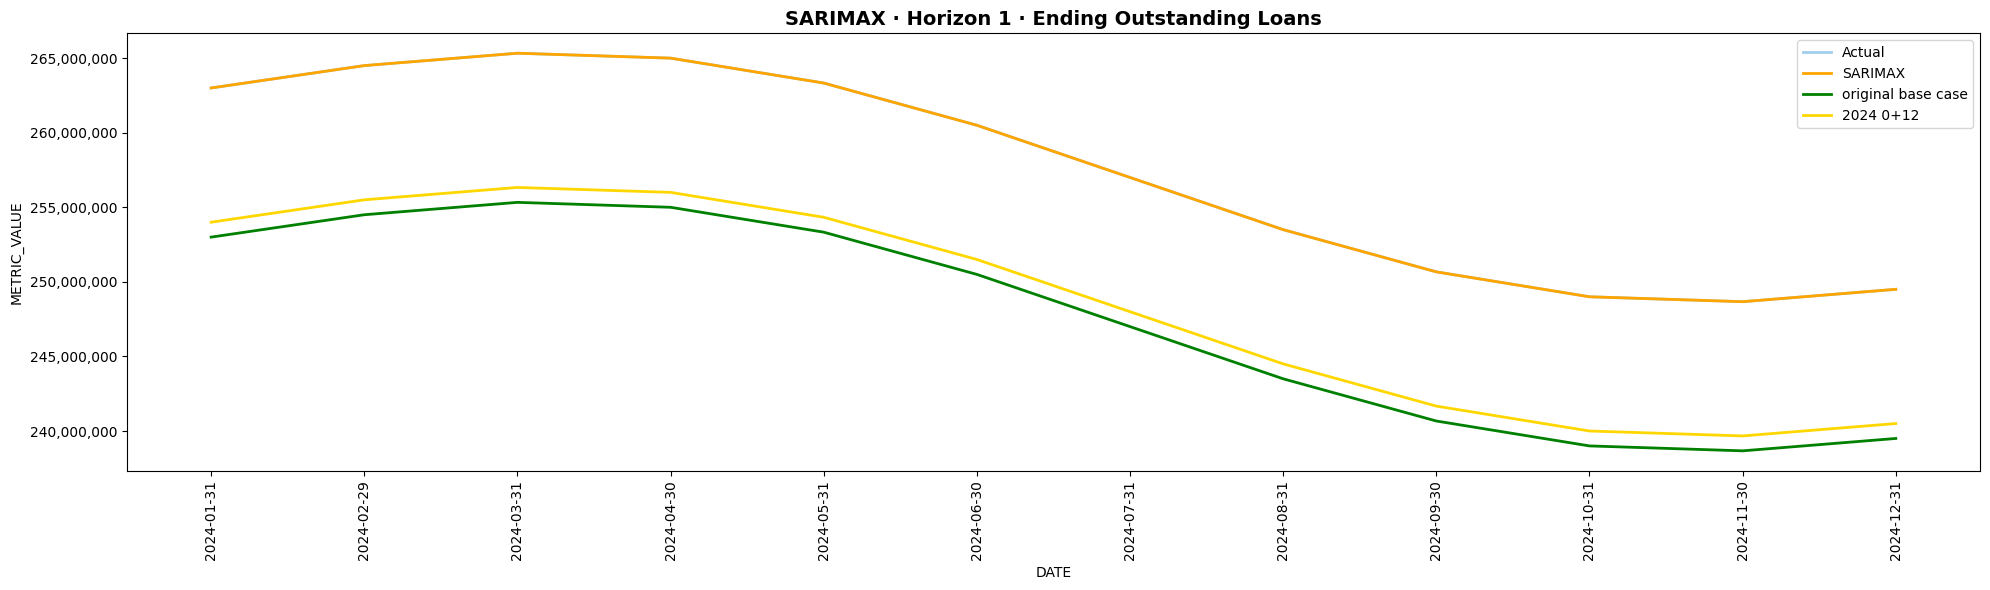

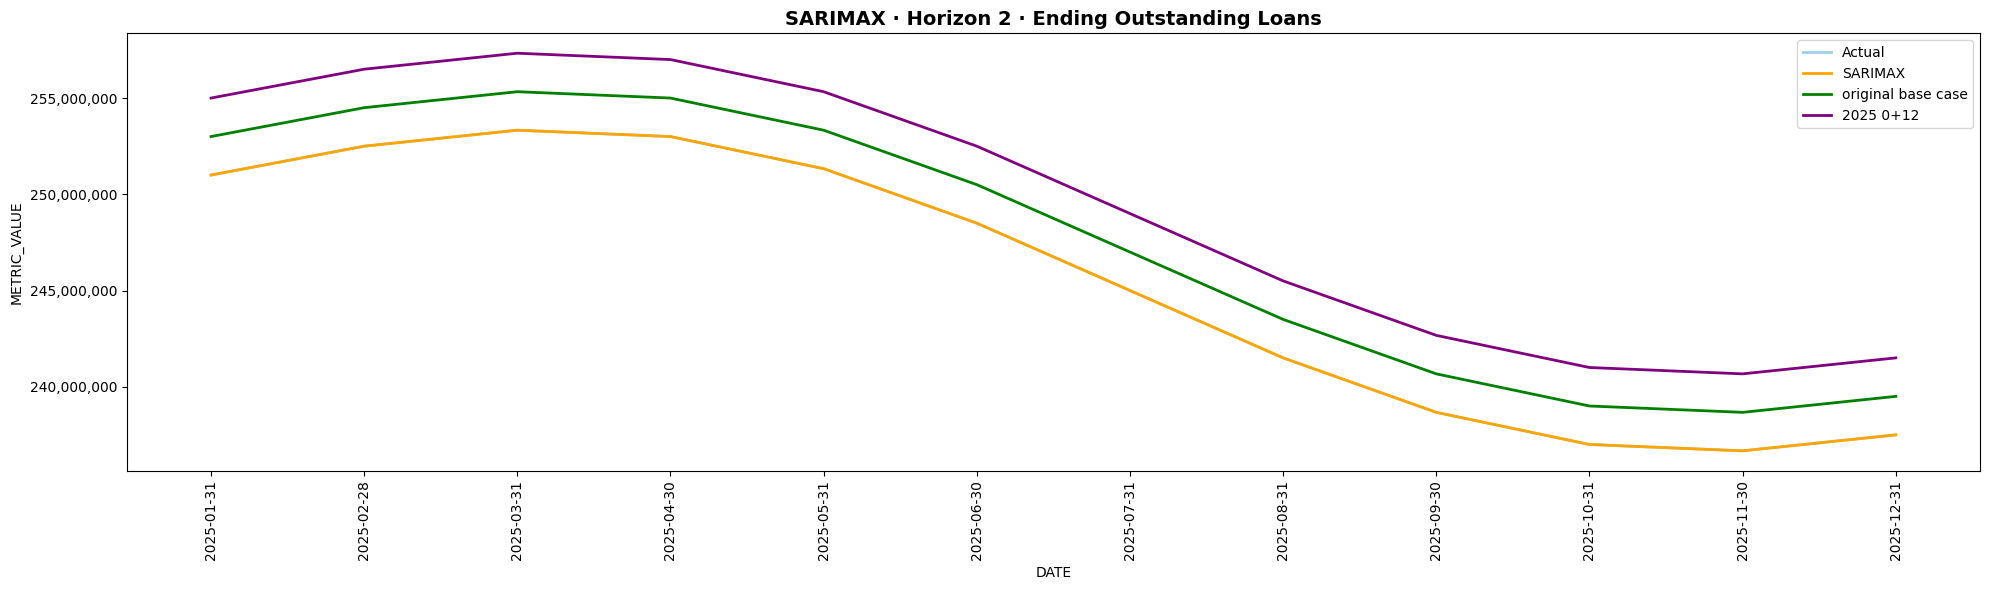

In [105]:
plot_results(pred_df_h1, f"SARIMAX · Horizon 1 · {TARGET_METRIC}")
plot_results(pred_df_h2, f"SARIMAX · Horizon 2 · {TARGET_METRIC}")


## 10. Inference horizon forecasting

### 10.1 Direct forecasting for inference horizon

In [106]:
# -- Inference horizon ----------------------------------------------
pred_df_inf, result_inf = fit_and_forecast(
    train_y_inf, test_y_inf, train_x_inf, test_x_inf, best_params
)
print("Inference forecast complete.")

Inference forecast complete.


### 10.2 Add Benchmark Series to Inference Horizons

In [107]:
benchmark_frames = []
for label in BENCHMARK_LABELS_INFER:
    bdf = get_benchmark(
        metric_df, portfolio, sub_portfolio,
        TARGET_METRIC, test_y_inf.index, label,
    )
    if not bdf.empty:
        benchmark_frames.append(bdf)

# Rebuild pred_df_inf with benchmarks appended
pred_df_inf = build_pred_df(
    forecast_values = pred_df_inf[pred_df_inf["FORECAST_TYPE"] == "SARIMAX"]["METRIC_VALUE"].values,
    test_series     = test_y_inf,
    model_label     = "SARIMAX",
    benchmark_dfs   = benchmark_frames,
)

### 10.3 Error metrics per horizon

In [108]:
# Inference metrics (partial actuals are ok)
clean_inf = drop_missing_actuals(pred_df_inf)
if clean_inf[clean_inf["FORECAST_TYPE"] == "Actual"].empty:
    print("\nInference - no actuals available for evaluation.")
else:
    evaluate_pred_df(
        clean_inf,
        ["SARIMAX"] + BENCHMARK_LABELS_INFER,
        TARGET_METRIC,
    )



═══════════════════════════════════════════════════════
  Error Metrics — Ending Outstanding Loans
═══════════════════════════════════════════════════════
  SARIMAX
    MAPE  : 19.95%
    SMAPE : 22.17%
    MAE   :       59,900,000
    RMSE  :       59,907,401
  2026 0+12 — no data
  original base case — no data
═══════════════════════════════════════════════════════


### 10.4 Inference horizon plot

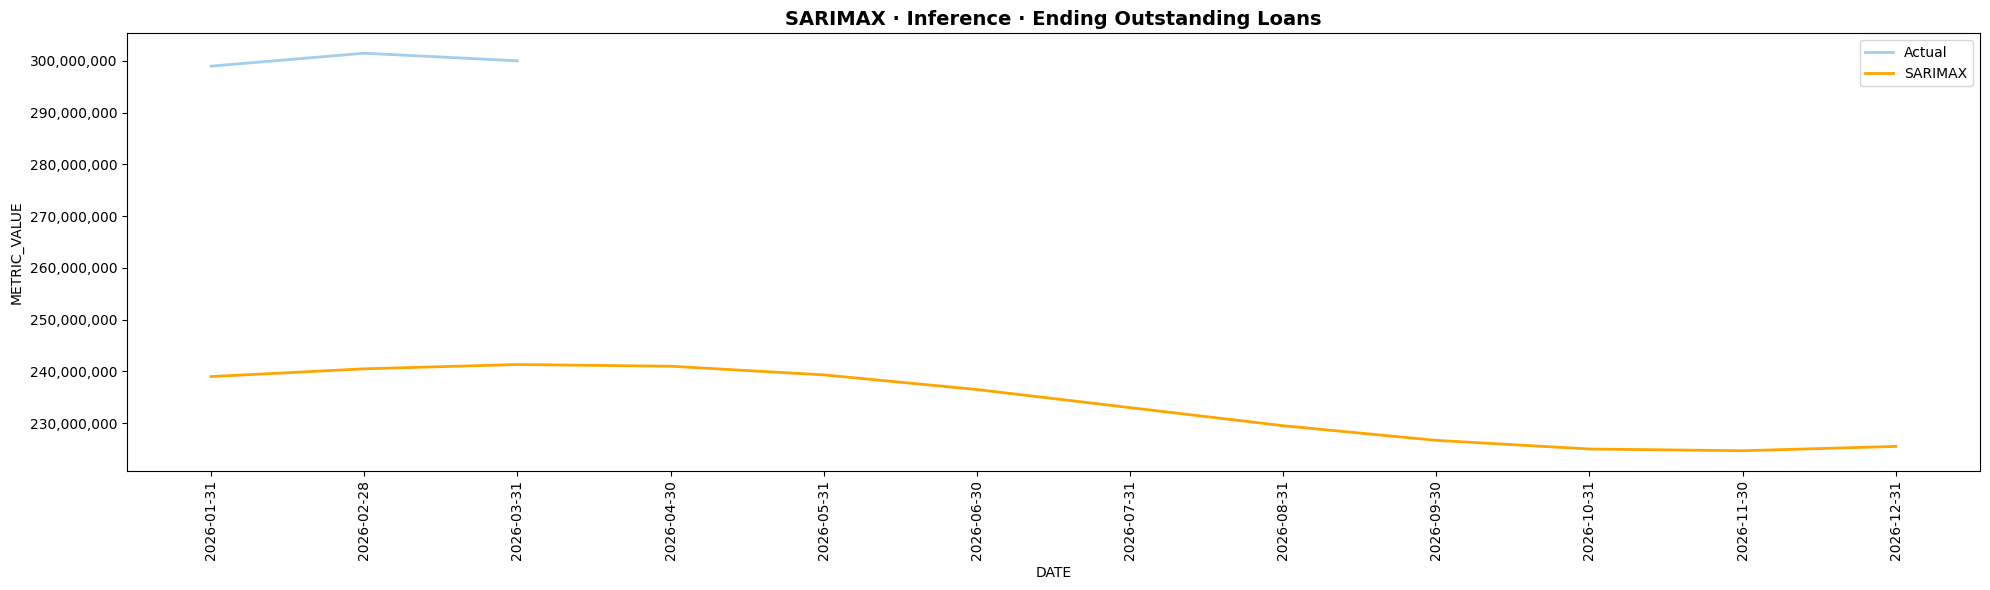

In [109]:
plot_results(pred_df_inf, f"SARIMAX · Inference · {TARGET_METRIC}")

## 12 · Export Forecast

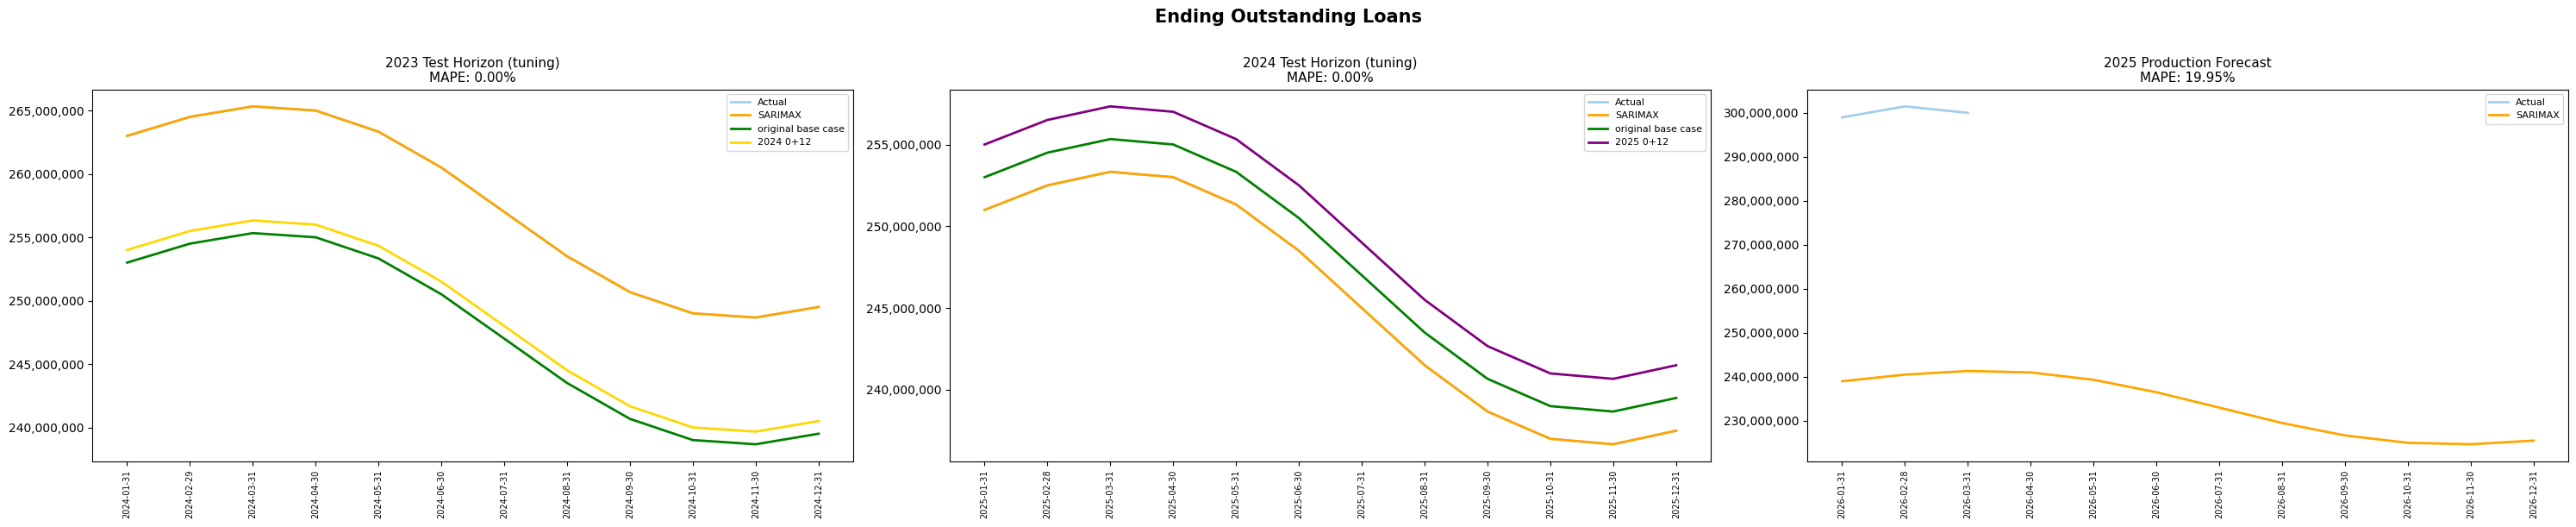

In [110]:
plot_all_horizons(
    pred_2024     = pred_df_h2,
    pred_2025     = pred_df_inf,
    target_metric = TARGET_METRIC,
    pred_2023     = pred_df_h1 if WEIGHTED_TUNING else None,
)


In [111]:
# print the final model summary for diagnostics
print(result_inf.summary())


                                     SARIMAX Results                                      
Dep. Variable:           Ending Outstanding Loans   No. Observations:                   25
Model:             SARIMAX(0, 1, 0)x(1, 0, 0, 12)   Log Likelihood                 127.128
Date:                            Wed, 29 Apr 2026   AIC                           -248.256
Time:                                    12:48:11   BIC                           -246.801
Sample:                                12-31-2023   HQIC                          -248.794
                                     - 12-31-2025                                         
Covariance Type:                              opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Portfolio_Acquired          0         -0        nan        nan           0           0
ar.S.L12   

In [43]:
# Save inference-horizon SARIMAX predictions to CSV
out = (
    pred_df_inf[pred_df_inf["FORECAST_TYPE"] == "SARIMAX"]
    [["DATE", "METRIC_VALUE"]]
    .rename(columns={"METRIC_VALUE": TARGET_METRIC})
)
file_name = f"{TARGET_METRIC.replace(' ', '_')}_inference_forecast.csv"
out.to_csv(file_name, index=False)
print("Saved:", file_name)
out


Saved: Ending_Outstanding_Loans_inference_forecast.csv


,DATE,Ending Outstanding Loans
12,2025-01-31,2.510000e+08
13,2025-02-28,2.525000e+08
14,2025-03-31,2.533301e+08
15,2025-04-30,2.530000e+08
16,2025-05-31,2.513301e+08
17,2025-06-30,2.485000e+08
18,2025-07-31,2.450000e+08
19,2025-08-31,2.415000e+08
20,2025-09-30,2.386699e+08
21,2025-10-31,2.370000e+08
